<style>
.jp-RenderedHTMLCommon,
.text_cell_render,
.jp-MarkdownOutput {
    font-family: Tahoma, Arial, "Noto Sans Arabic", "DejaVu Sans", sans-serif !important;
    font-size: 16px !important;
    line-height: 1.95 !important;
    direction: rtl !important;
    text-align: right !important;
    color: #111 !important;
}

h1 { font-size: 32px !important; margin-top: 8px !important; }
h2 { font-size: 26px !important; margin-top: 24px !important; }
h3 { font-size: 20px !important; margin-top: 18px !important; }

bdi[dir="ltr"], span[dir="ltr"] {
    direction: ltr !important;
    unicode-bidi: isolate !important;
    font-family: Arial, "DejaVu Sans", sans-serif !important;
}

code, pre, .jp-CodeCell {
    font-family: "DejaVu Sans Mono", Consolas, monospace !important;
    direction: ltr !important;
    text-align: left !important;
}

.note-box {
    border-right: 5px solid #2e7d32;
    background: #f1f8e9;
    padding: 12px 16px;
    border-radius: 10px;
    margin: 10px 0;
}

.warning-box {
    border-right: 5px solid #ef6c00;
    background: #fff3e0;
    padding: 12px 16px;
    border-radius: 10px;
    margin: 10px 0;
}

.flow-box {
    background: #f7f7f7;
    border: 1px solid #ddd;
    border-radius: 10px;
    padding: 12px 16px;
    margin: 10px 0;
}

table { margin-right: auto !important; margin-left: 0 !important; }
</style>

<div dir="rtl">

# جلسه ۸: <bdi dir="ltr">Clustering and Unsupervised Learning</bdi>

<b>مدت جلسه:</b> ۲ ساعت

## سؤال اصلی جلسه

اگر <bdi dir="ltr">Target</bdi> نداشته باشیم، چطور می‌توانیم ساختارها و گروه‌های موجود در داده را پیدا کنیم؟

## مسیر جلسه

<bdi dir="ltr">Unsupervised Learning → Distance → Scaling → K-Means → Elbow Method → Silhouette Score → DBSCAN → Cluster Interpretation</bdi>

## اهداف یادگیری

در پایان این جلسه، دانشجو باید بتواند:

- تفاوت <bdi dir="ltr">Supervised</bdi> و <bdi dir="ltr">Unsupervised Learning</bdi> را توضیح دهد؛
- مفهوم Distance و Similarity را بداند؛
- دلیل اهمیت <bdi dir="ltr">Feature Scaling</bdi> در Clustering را توضیح دهد؛
- <bdi dir="ltr">K-Means</bdi> را اجرا کند و مفهوم Centroid را بداند؛
- از <bdi dir="ltr">Elbow Method</bdi> و <bdi dir="ltr">Silhouette Score</bdi> برای بررسی تعداد Clusterها استفاده کند؛
- <bdi dir="ltr">DBSCAN</bdi> را اجرا کند و Noise را تشخیص دهد؛
- Clusterهای ساخته‌شده را با استفاده از Featureهای Dataset تفسیر کند.

</div>

<div dir="rtl">

## ۱. آماده‌سازی <bdi dir="ltr">Diabetes Dataset</bdi>

در این جلسه همان Dataset جلسات قبل را نگه می‌داریم، اما این بار یک تفاوت مهم داریم:

> برای ساخت Clusterها از <bdi dir="ltr">Target</bdi> استفاده نمی‌کنیم.

مدل فقط Featureهای <bdi dir="ltr">X</bdi> را می‌بیند و خودش تلاش می‌کند گروه‌های موجود در داده را پیدا کند.

<bdi dir="ltr">y</bdi> را نگه می‌داریم، اما فقط در انتهای جلسه برای تفسیر آموزشی Clusterها به آن نگاه می‌کنیم.

</div>

In [1]:
from sklearn.datasets import load_diabetes

# Load the Diabetes dataset.
data = load_diabetes(as_frame=True, scaled=False)

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(list(X.columns))
print("\nFirst 5 rows:")
print(X.head())

X shape: (442, 10)
y shape: (442,)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 rows:
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0


<div dir="rtl">

## ۲. مقدمه‌ای بر <bdi dir="ltr">Unsupervised Learning</bdi>

در <bdi dir="ltr">Supervised Learning</bdi> معمولاً داریم:

<bdi dir="ltr">X + y → Model</bdi>

اما در <bdi dir="ltr">Unsupervised Learning</bdi> فقط <bdi dir="ltr">X</bdi> داریم.

هدف می‌تواند پیدا کردن:

- Groupها یا Clusterها
- Patternهای پنهان
- Observationهای غیرعادی

باشد.

<p align="center">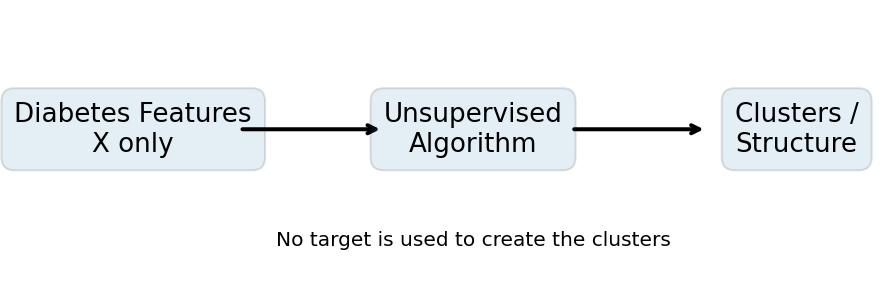</p>

</div>

<div dir="rtl">

### <bdi dir="ltr">Supervised vs Unsupervised</bdi>

| ویژگی | <bdi dir="ltr">Supervised</bdi> | <bdi dir="ltr">Unsupervised</bdi> |
|---|---|---|
| Target | داریم | نداریم |
| هدف | Prediction | پیدا کردن Structure |
| مثال | Regression / Classification | Clustering |
| ارزیابی | با Target واقعی | معمولاً با معیارهای داخلی و تفسیر |

</div>

<div dir="rtl">

## ۳. <bdi dir="ltr">Distance and Similarity Measures</bdi>

Clustering معمولاً به این سؤال وابسته است:

> کدام Observationها به هم نزدیک‌تر یا شبیه‌تر هستند؟

سه مفهوم رایج:

- <bdi dir="ltr">Euclidean Distance</bdi>: فاصله‌ی مستقیم بین دو نقطه
- <bdi dir="ltr">Manhattan Distance</bdi>: مجموع فاصله‌ها در هر محور
- <bdi dir="ltr">Cosine Similarity</bdi>: شباهت جهت دو Vector

در این جلسه تمرکز اصلی ما روی Euclidean Distance است، چون <bdi dir="ltr">K-Means</bdi> و تنظیم پیش‌فرض <bdi dir="ltr">DBSCAN</bdi> با فاصله‌ی Euclidean ارتباط مستقیم دارند.

<p align="center">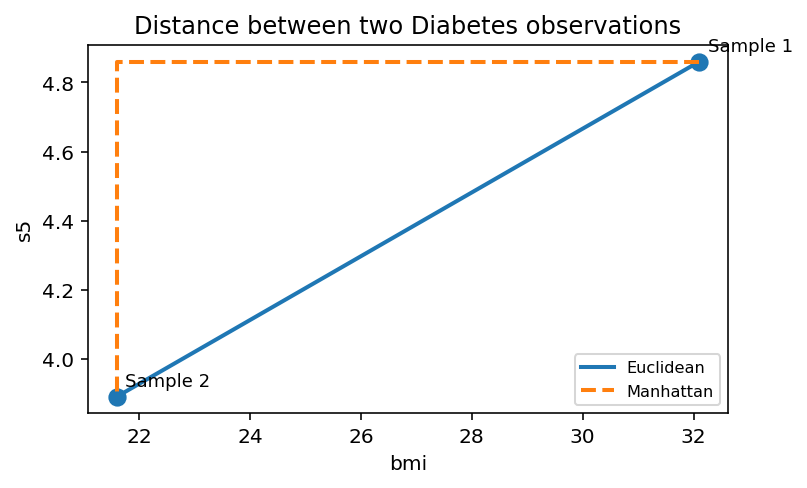</p>

</div>

In [2]:
import numpy as np

# Use two real observations from the Diabetes dataset.
p1 = X[["bmi", "s5"]].iloc[0].values
p2 = X[["bmi", "s5"]].iloc[1].values

# Euclidean distance.
euclidean = np.sqrt(np.sum((p1 - p2) ** 2))

# Manhattan distance.
manhattan = np.sum(np.abs(p1 - p2))

print("Point 1:", p1)
print("Point 2:", p2)
print("Euclidean distance:", round(euclidean, 3))
print("Manhattan distance:", round(manhattan, 3))

Point 1: [32.1     4.8598]
Point 2: [21.6     3.8918]
Euclidean distance: 10.545
Manhattan distance: 11.468


<div dir="rtl">

## ۴. چرا <bdi dir="ltr">Feature Scaling</bdi> مهم است؟

اگر یک Feature اعداد خیلی بزرگ‌تری از Feature دیگر داشته باشد، در محاسبه‌ی Distance اثر بیشتری می‌گذارد.

مثلاً در Diabetes Dataset، Featureها Rangeهای یکسانی ندارند.

### قبل از Scaling

<p align="center">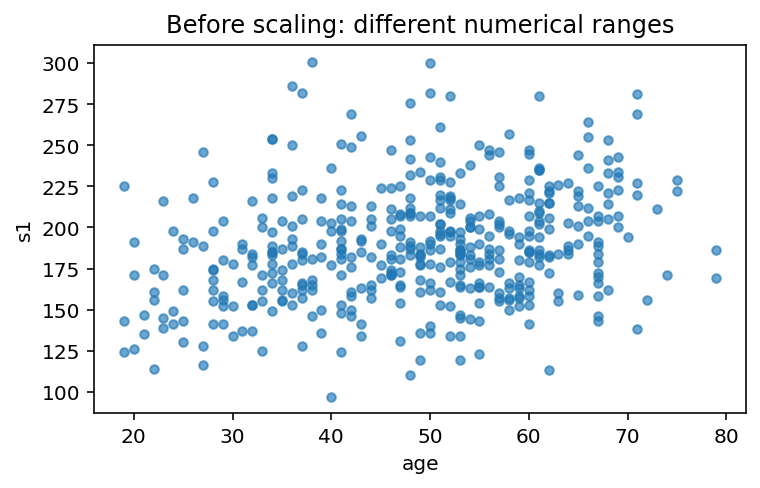</p>

### بعد از <bdi dir="ltr">StandardScaler</bdi>

<p align="center">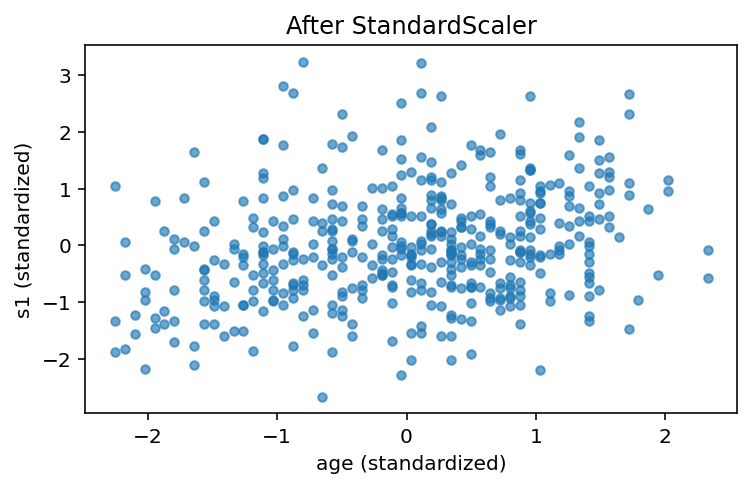</p>

</div>

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert numpy to pandas
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(X_scaled.head().round(3))

     age    sex    bmi     bp     s1     s2     s3     s4     s5     s6
0  0.801  1.065  1.297  0.460 -0.930 -0.732 -0.912 -0.054  0.419 -0.371
1 -0.040 -0.939 -1.082 -0.554 -0.178 -0.403  1.564 -0.830 -1.437 -1.938
2  1.793  1.065  0.935 -0.119 -0.959 -0.719 -0.680 -0.054  0.060 -0.545
3 -1.872 -0.939 -0.244 -0.771  0.256  0.525 -0.758  0.721  0.477 -0.197
4  0.113 -0.939 -0.765  0.460  0.083  0.328  0.171 -0.054 -0.673 -0.981


<div dir="rtl">

## ۵. <bdi dir="ltr">K-Means Clustering</bdi>

ایده‌ی K-Means ساده است:

1. تعداد Clusterها یعنی <bdi dir="ltr">K</bdi> را مشخص می‌کنیم.
2. برای هر Cluster یک مرکز به نام <bdi dir="ltr">Centroid</bdi> داریم.
3. هر Observation به نزدیک‌ترین Centroid نسبت داده می‌شود.
4. Centroidها دوباره محاسبه می‌شوند.
5. این مراحل تکرار می‌شوند تا Clusterها پایدار شوند.

در شکل زیر Clusterها با استفاده از **تمام ۱۰ Feature استانداردشده** ساخته شده‌اند، اما فقط برای نمایش، آن‌ها را روی <bdi dir="ltr">bmi</bdi> و <bdi dir="ltr">s5</bdi> می‌بینیم.

<p align="center">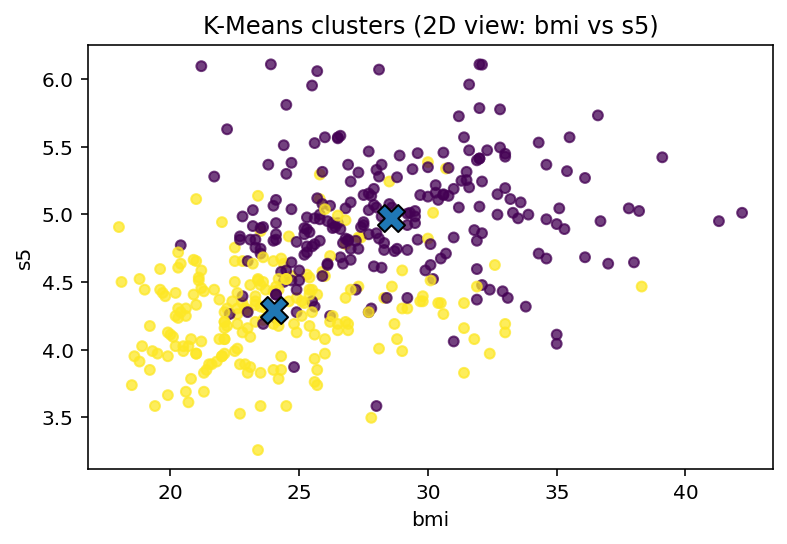</p>

</div>

<div dir="rtl" class="note-box">

### نکته

در K-Means باید تعداد Clusterها یعنی <bdi dir="ltr">K</bdi> را از قبل مشخص کنیم.

اما از کجا بفهمیم K مناسب چند است؟

دو ابزار رایج:

- <bdi dir="ltr">Elbow Method</bdi>
- <bdi dir="ltr">Silhouette Score</bdi>

</div>

<div dir="rtl">

## ۶. <bdi dir="ltr">Elbow Method</bdi>

K-Means مقداری به نام <bdi dir="ltr">Inertia</bdi> دارد.

Inertia نشان می‌دهد Observationها در مجموع چقدر از Centroidهای Cluster خود فاصله دارند.

- Inertia کمتر یعنی نقاط به مرکز Cluster خود نزدیک‌ترند.
- با افزایش Inertia، k تقریباً همیشه کمتر می‌شود.
- در Elbow Method دنبال نقطه‌ای می‌گردیم که بعد از آن کاهش Inertia دیگر خیلی شدید نباشد.

<p align="center">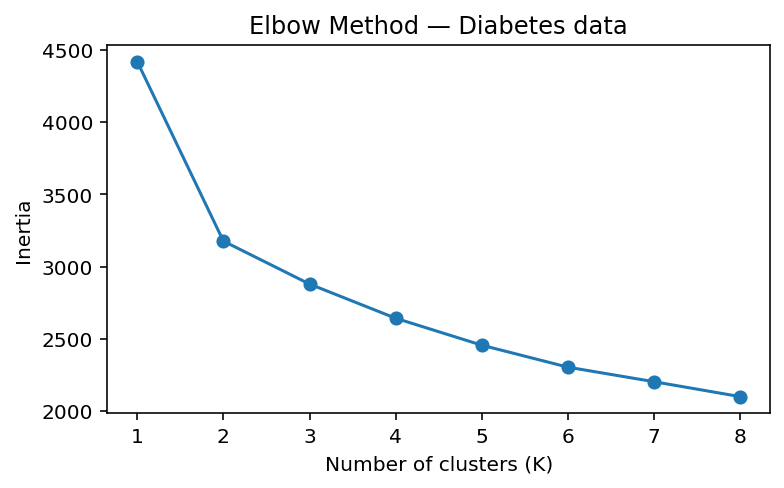</p>

در این Dataset، Elbow خیلی کاملاً تیز نیست؛ بنابراین بهتر است نتیجه را همراه با معیار دیگری مثل Silhouette بررسی کنیم.

</div>

In [7]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 9):

    model = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

    print(
        "K =", k,
        "Inertia =", round(model.inertia_, 2)
    )

K = 1 Inertia = 4420.0
K = 2 Inertia = 3176.65
K = 3 Inertia = 2879.2
K = 4 Inertia = 2642.37
K = 5 Inertia = 2455.65
K = 6 Inertia = 2303.37
K = 7 Inertia = 2202.62
K = 8 Inertia = 2099.32


<div dir="rtl">

## ۷. <bdi dir="ltr">Silhouette Score</bdi>

Silhouette بررسی می‌کند هر Observation:

- چقدر به Cluster خودش نزدیک است؛
- و چقدر از Clusterهای دیگر دور است.

مقدار آن تقریباً بین <bdi dir="ltr">-1</bdi> و <bdi dir="ltr">1</bdi> است:

- نزدیک <bdi dir="ltr">1</bdi>: Cluster نسبتاً واضح
- نزدیک <bdi dir="ltr">0</bdi>: Clusterها overlap دارند
- مقدار منفی: بعضی Observationها احتمالاً به Cluster مناسب نسبت داده نشده‌اند

<p align="center">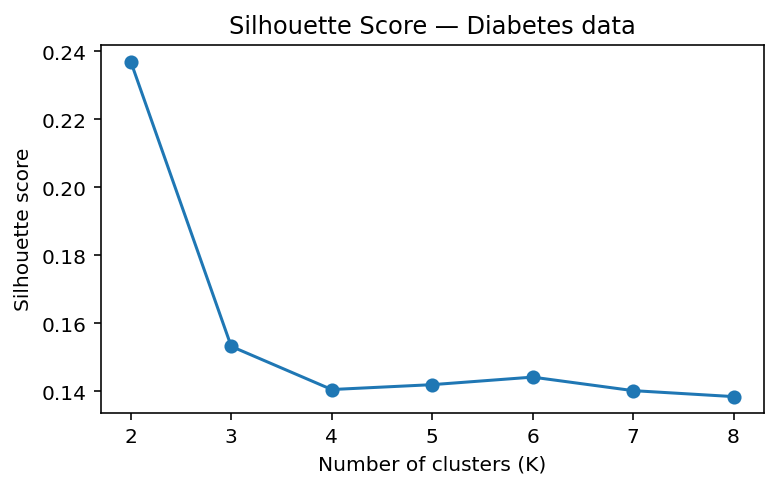</p>

در این مثال، بین Kهای بررسی‌شده، <bdi dir="ltr">K=2</bdi> بیشترین Silhouette Score را دارد.

</div>

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(
        "K =", k,
        "Silhouette =", round(score, 3)
    )

K = 2 Silhouette = 0.237
K = 3 Silhouette = 0.153
K = 4 Silhouette = 0.141
K = 5 Silhouette = 0.142
K = 6 Silhouette = 0.144
K = 7 Silhouette = 0.14
K = 8 Silhouette = 0.138


<div dir="rtl">

## ۸. ساخت <bdi dir="ltr">Final K-Means Model</bdi>

برای ادامه‌ی مثال، از <bdi dir="ltr">K=2</bdi> استفاده می‌کنیم.

خروجی <bdi dir="ltr">fit_predict</bdi> برای هر Observation شماره‌ی Cluster را برمی‌گرداند.

</div>

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=0,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("First 20 cluster labels:")
print(kmeans_labels[:20])

First 20 cluster labels:
[0 1 0 0 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1]


In [11]:
import pandas as pd

labels_df = pd.DataFrame(
    kmeans_labels,
    columns=["Cluster"]
)

print(labels_df["Cluster"].value_counts())

Cluster
0    228
1    214
Name: count, dtype: int64


<div dir="rtl">

### <bdi dir="ltr">Cluster Centers</bdi>

هر سطر از <bdi dir="ltr">cluster_centers_</bdi> یک Centroid است.

چون مدل را روی داده‌های Standardized آموزش داده‌ایم، برای تفسیر راحت‌تر Centroidها را به Scale اصلی Dataset برمی‌گردانیم.

</div>

In [14]:
import pandas as pd

centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_table = pd.DataFrame(
    centers_original,
    columns=X.columns
)

print(centers_table.round(2))

     age   sex    bmi      bp      s1      s2     s3    s4    s5     s6
0  53.13  1.63  28.57  100.62  206.72  131.97  43.06  4.97  4.97  97.18
1  43.60  1.30  24.04   88.28  170.41   97.83  56.96  3.11  4.29  84.95


<div dir="rtl">

## ۹. <bdi dir="ltr">DBSCAN</bdi>

DBSCAN با K-Means فرق دارد.

به‌جای اینکه از قبل تعداد Clusterها را مشخص کنیم، DBSCAN به **چگالی نقاط** نگاه می‌کند.

دو Hyperparameter مهم:

- <bdi dir="ltr">eps</bdi>: حداکثر فاصله برای اینکه نقاط Neighbor محسوب شوند
- <bdi dir="ltr">min_samples</bdi>: حداقل تعداد Observation لازم برای یک ناحیه‌ی متراکم

DBSCAN می‌تواند بعضی Observationها را به عنوان <bdi dir="ltr">Noise</bdi> تشخیص دهد.

در Noise، sklearn با Label برابر <bdi dir="ltr">-1</bdi> مشخص می‌شود.

<p align="center">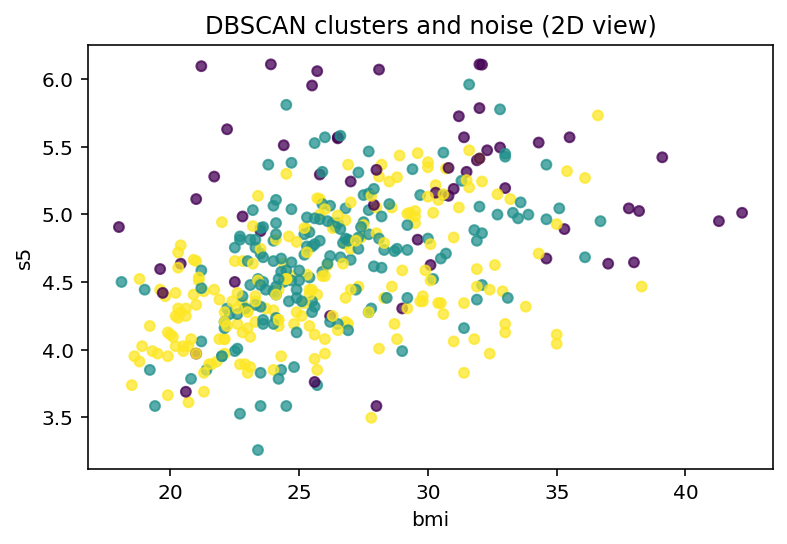</p>

در شکل فقط نمای <bdi dir="ltr">bmi</bdi> و <bdi dir="ltr">s5</bdi> دیده می‌شود، اما DBSCAN با تمام ۱۰ Feature استانداردشده اجرا شده است.

</div>

In [15]:
import pandas as pd
from sklearn.cluster import DBSCAN

model = DBSCAN(
    eps=2.0,
    min_samples=5
)

dbscan_labels = model.fit_predict(X_scaled)

labels_df = pd.DataFrame(
    dbscan_labels,
    columns=["Cluster"]
)

print("Cluster / noise counts:")
print(labels_df["Cluster"].value_counts().sort_index())

Cluster / noise counts:
Cluster
-1     56
 0    175
 1    211
Name: count, dtype: int64


<div dir="rtl">

## ۱۰. <bdi dir="ltr">K-Means vs DBSCAN</bdi>

| ویژگی | <bdi dir="ltr">K-Means</bdi> | <bdi dir="ltr">DBSCAN</bdi> |
|---|---|---|
| تعداد Cluster | باید K را مشخص کنیم | از قبل لازم نیست |
| مفهوم اصلی | فاصله تا Centroid | Density |
| Noise | به همه‌ی نقاط Cluster می‌دهد | می‌تواند Noise بسازد |
| شکل Cluster | برای گروه‌های تقریباً فشرده مناسب‌تر | شکل‌های پیچیده‌تر را هم می‌تواند پیدا کند |
| Scaling | مهم | مهم |
| پارامتر مهم | <bdi dir="ltr">n_clusters</bdi> | <bdi dir="ltr">eps, min_samples</bdi> |

</div>

<div dir="rtl">

## ۱۱. <bdi dir="ltr">Cluster Interpretation</bdi>

بعد از ساخت Clusterها، باید بفهمیم هر Cluster چه ویژگی‌هایی دارد.

یک روش ساده:

> میانگین Featureها را در هر Cluster مقایسه کنیم.

شکل زیر میانگین Standardized چند Feature را برای دو Cluster نشان می‌دهد.

<p align="center">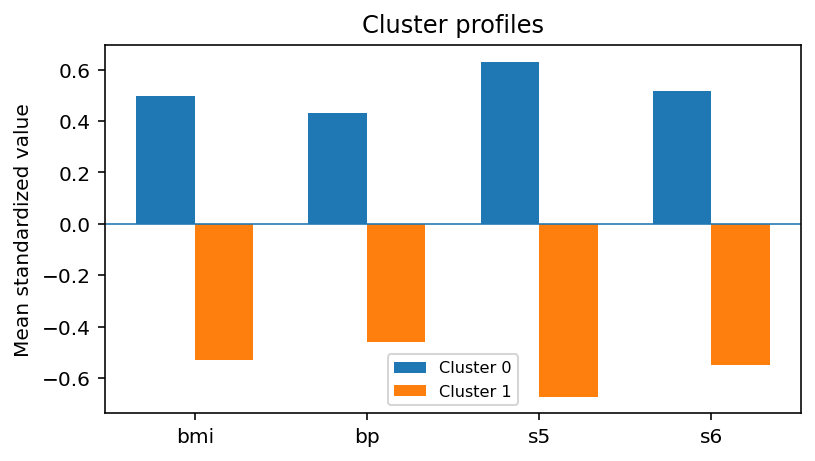</p>

مقدار بالاتر از صفر یعنی میانگین آن Feature در آن Cluster بالاتر از میانگین کل Dataset است.

مقدار پایین‌تر از صفر یعنی پایین‌تر از میانگین کل Dataset است.

</div>

In [16]:
import pandas as pd

cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels

cluster_summary = cluster_data.groupby("Cluster").mean()

print(cluster_summary[["age", "bmi", "bp", "s5", "s6"]].round(2))

           age    bmi      bp    s5     s6
Cluster                                   
0        53.13  28.57  100.62  4.97  97.18
1        43.60  24.04   88.29  4.29  84.95


<div dir="rtl" class="note-box">

### استفاده از Target فقط برای تفسیر

تا اینجا <bdi dir="ltr">y</bdi> در ساخت Clusterها هیچ نقشی نداشته است.

حالا **بعد از پایان Clustering** می‌توانیم فقط برای شناخت بهتر Clusterها ببینیم میانگین Target در هر Cluster چقدر است.

این کار Supervised Training نیست؛ یک تحلیل Post-hoc برای تفسیر Clusterها است.

</div>

In [17]:
import pandas as pd

target_check = pd.DataFrame({
    "Cluster": kmeans_labels,
    "Target": y
})

print(target_check.groupby("Cluster")["Target"].mean().round(2))

Cluster
0    188.35
1    113.55
Name: Target, dtype: float64


<div dir="rtl">

## ۱۲. اشتباه‌های رایج در Clustering

- Scaling نکردن Featureها قبل از روش‌های Distance-based
- فرض اینکه هر Cluster حتماً یک معنی واقعی و مشخص دارد
- انتخاب K فقط با نگاه به یک نمودار
- استفاده از K-Means برای هر نوع شکل داده بدون بررسی
- فرض اینکه Labelهای Cluster مثل <bdi dir="ltr">0</bdi> و <bdi dir="ltr">1</bdi> ترتیب یا ارزش خاصی دارند
- فرض اینکه Noise در DBSCAN حتماً «داده‌ی اشتباه» است

<b>نکته:</b> شماره‌ی Cluster فقط یک Label است. Cluster 1 الزاماً بهتر یا بزرگ‌تر از Cluster 0 نیست.

</div>

<div dir="rtl">

## ۱۳. Workflow ساده برای Clustering

<div class="flow-box">
<bdi dir="ltr">
1. Select Features<br>
↓<br>
2. Scale Features<br>
↓<br>
3. Choose a Clustering Method<br>
↓<br>
4. Check Elbow / Silhouette or Density Settings<br>
↓<br>
5. Fit the Model<br>
↓<br>
6. Inspect Cluster Sizes<br>
↓<br>
7. Interpret Cluster Profiles
</bdi>
</div>

</div>

<div dir="rtl">

## ۱۴. Quiz کوتاه

### سؤال ۱
در <bdi dir="ltr">Unsupervised Learning</bdi> برای ساخت مدل معمولاً چه چیزی نداریم؟

<span dir="ltr">A.</span> Featureها  
<span dir="ltr">B.</span> Target  
<span dir="ltr">C.</span> Observationها

### سؤال ۲
چرا قبل از K-Means معمولاً Scaling انجام می‌دهیم؟

<span dir="ltr">A.</span> چون K-Means به Distance وابسته است  
<span dir="ltr">B.</span> چون تعداد Featureها را کم می‌کند  
<span dir="ltr">C.</span> چون Target را می‌سازد

### سؤال ۳
در K-Means، <bdi dir="ltr">Centroid</bdi> چیست؟

<span dir="ltr">A.</span> مرکز Cluster  
<span dir="ltr">B.</span> Noise  
<span dir="ltr">C.</span> Target

### سؤال ۴
Silhouette Score بالاتر معمولاً چه معنی دارد؟

<span dir="ltr">A.</span> جدایی بهتر Clusterها  
<span dir="ltr">B.</span> Featureهای بیشتر  
<span dir="ltr">C.</span> Target دقیق‌تر

### سؤال ۵
در DBSCAN، Label برابر <bdi dir="ltr">-1</bdi> معمولاً چیست؟

<span dir="ltr">A.</span> Cluster اول  
<span dir="ltr">B.</span> Noise  
<span dir="ltr">C.</span> Centroid

</div>

<div dir="rtl">

<details>
<summary><b>پاسخ Quiz — برای مشاهده کلیک کنید</b></summary>

<p><b>۱. B —</b> Target</p>
<p><b>۲. A —</b> چون K-Means به Distance وابسته است.</p>
<p><b>۳. A —</b> مرکز Cluster</p>
<p><b>۴. A —</b> جدایی بهتر Clusterها</p>
<p><b>۵. B —</b> Noise</p>

</details>

</div>

<div dir="rtl">

## ۱۵. تمرین ۱ — تغییر <bdi dir="ltr">K</bdi>

K-Means را با مقادیر زیر اجرا کنید:

- <bdi dir="ltr">K = 2</bdi>
- <bdi dir="ltr">K = 3</bdi>
- <bdi dir="ltr">K = 4</bdi>

برای هر مدل Silhouette Score را حساب کنید.

کدام مقدار K امتیاز بالاتری دارد؟

</div>

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 2

model = KMeans(
    n_clusters=k,
    random_state=0,
    n_init=10
)

labels = model.fit_predict(X_scaled)
score = silhouette_score(X_scaled, labels)

print("K =", k)
print("Silhouette =", round(score, 3))

K = 2
Silhouette = 0.237


<div dir="rtl">

## ۱۶. تمرین ۲ — تغییر <bdi dir="ltr">eps</bdi> در DBSCAN

مقادیر زیر را امتحان کنید:

- <bdi dir="ltr">eps = 1.6</bdi>
- <bdi dir="ltr">eps = 1.8</bdi>
- <bdi dir="ltr">eps = 2.0</bdi>
- <bdi dir="ltr">eps = 2.2</bdi>

برای هر حالت بررسی کنید:

- چند Cluster ساخته می‌شود؟
- چند Observation به عنوان Noise شناخته می‌شود؟

</div>

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN

eps = 2.0

model = DBSCAN(
    eps=eps,
    min_samples=5
)

labels = model.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("eps =", eps)
print("Clusters =", n_clusters)
print("Noise points =", n_noise)

eps = 2.0
Clusters = 2
Noise points = 56


<div dir="rtl">

## ۱۷. تمرین ۳ — تفسیر Clusterها

برای K-Means با <bdi dir="ltr">K=2</bdi>، میانگین Featureهای زیر را در هر Cluster گزارش کنید:

- <bdi dir="ltr">bmi</bdi>
- <bdi dir="ltr">bp</bdi>
- <bdi dir="ltr">s5</bdi>

### سؤال

با توجه به این میانگین‌ها، دو Cluster چه تفاوت‌هایی با هم دارند؟

</div>

In [ ]:
import pandas as pd

exercise_data = X.copy()
exercise_data["Cluster"] = kmeans_labels

print(
    exercise_data.groupby("Cluster")[["bmi", "bp", "s5"]]
    .mean()
    .round(2)
)

           bmi      bp    s5
Cluster                     
0        28.57  100.62  4.97
1        24.04   88.29  4.29


<div dir="rtl">

# جمع‌بندی جلسه ۸

در این جلسه دیدیم که در <bdi dir="ltr">Unsupervised Learning</bdi> بدون استفاده از Target می‌توانیم ساختارهایی در Featureها پیدا کنیم.

مفاهیم اصلی:

- <bdi dir="ltr">Distance and Similarity</bdi>
- اهمیت <bdi dir="ltr">Feature Scaling</bdi>
- <bdi dir="ltr">K-Means Clustering</bdi>
- <bdi dir="ltr">Centroid</bdi>
- <bdi dir="ltr">Elbow Method</bdi>
- <bdi dir="ltr">Silhouette Score</bdi>
- <bdi dir="ltr">DBSCAN</bdi>
- <bdi dir="ltr">Noise</bdi>
- <bdi dir="ltr">Cluster Interpretation</bdi>

> پیام اصلی جلسه:  
> **در Clustering فقط ساختن Cluster کافی نیست؛ باید Scaling، معیار انتخاب مدل و تفسیر Clusterها را هم بررسی کنیم.**

</div>